# 07 Recommendation Confidence
Этап 13: top-k recommendations + confidence/uncertainty layer.

In [3]:
import json
from pathlib import Path
import importlib
import numpy as np
import pandas as pd

from _shared_notebook_utils import RESEARCH_CHECKPOINT_DIR

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
registry_path = ROOT / "artifacts" / "model_registry.json"
with open(registry_path, "r", encoding="utf-8") as f:
    registry = json.load(f)

active_model = registry["active_model"]
active_entry = registry["models"][active_model]
model_path = ROOT / active_entry["model_path"]
meta_path = ROOT / active_entry["meta_path"]

if not model_path.exists() or not meta_path.exists():
    raise FileNotFoundError(f"Model artifacts missing for active_model={active_model}: {model_path} / {meta_path}")

# Load split dataframes from frozen checkpoint.
baseline_dir = RESEARCH_CHECKPOINT_DIR / "baseline"
val_df = pd.read_pickle(baseline_dir / "val_df.pkl")
test_df = pd.read_pickle(baseline_dir / "test_df.pkl")

with open(meta_path, "r", encoding="utf-8") as f:
    model_meta = json.load(f)

catboost_mod = importlib.import_module("catboost")
CatBoostClassifier = catboost_mod.CatBoostClassifier
model = CatBoostClassifier()
model.load_model(model_path.as_posix())

print("active_model =", active_model)
print("Loaded model:", model_path)
print("Loaded split shapes:", val_df.shape, test_df.shape)

active_model = baseline
Loaded model: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\catboost\baseline\model.cbm
Loaded split shapes: (5776566, 12) (5777014, 12)


In [4]:
# 7.1 Recommendation layer + confidence/uncertainty
feature_columns = model_meta.get("feature_columns", model_meta.get("feature_cols", []))
if not feature_columns:
    raise ValueError("feature columns are missing in model meta")

if "id_to_target" in model_meta:
    id_to_target = {int(k): str(v) for k, v in model_meta["id_to_target"].items()}
    class_names = np.asarray([id_to_target[i] for i in sorted(id_to_target.keys())], dtype=object)
elif "target_to_id" in model_meta:
    inv = {int(v): str(k) for k, v in model_meta["target_to_id"].items()}
    class_names = np.asarray([inv[i] for i in sorted(inv.keys())], dtype=object)
else:
    raise ValueError("No class mapping found in model meta")

for split_df in [val_df, test_df]:
    for col in ["history_1", "history_2", "history_3", "target"]:
        if col in split_df.columns:
            split_df[col] = split_df[col].astype("string")

X_val = val_df[feature_columns]
X_test = test_df[feature_columns]
val_proba = np.asarray(model.predict_proba(X_val))
test_proba = np.asarray(model.predict_proba(X_test))

if val_proba.shape[1] != len(class_names):
    raise ValueError(f"Class/proba mismatch for validation: {val_proba.shape[1]} vs {len(class_names)}")
if test_proba.shape[1] != len(class_names):
    raise ValueError(f"Class/proba mismatch for test: {test_proba.shape[1]} vs {len(class_names)}")

def extract_topk_arrays(proba_matrix, class_names_arr, max_k=5):
    max_k = min(int(max_k), proba_matrix.shape[1])
    top_idx_unsorted = np.argpartition(proba_matrix, -max_k, axis=1)[:, -max_k:]
    top_proba_unsorted = np.take_along_axis(proba_matrix, top_idx_unsorted, axis=1)
    sort_order = np.argsort(-top_proba_unsorted, axis=1)
    top_idx = np.take_along_axis(top_idx_unsorted, sort_order, axis=1)
    top_proba = np.take_along_axis(top_proba_unsorted, sort_order, axis=1)
    top_labels = class_names_arr[top_idx]
    return top_idx, top_proba, top_labels

def build_recommendation_df(split_df, top_labels, top_proba):
    rec_df = split_df[[c for c in ["history_1", "history_2", "history_3", "target"] if c in split_df.columns]].copy()
    rec_df["top1_pred"] = top_labels[:, 0]
    rec_df["top1_proba"] = top_proba[:, 0].astype(float)
    rec_df["top2_pred"] = top_labels[:, 1]
    rec_df["top2_proba"] = top_proba[:, 1].astype(float)
    rec_df["top3_pred"] = top_labels[:, 2]
    rec_df["top3_proba"] = top_proba[:, 2].astype(float)
    rec_df["top3_list"] = top_labels[:, 0].astype(str) + " | " + top_labels[:, 1].astype(str) + " | " + top_labels[:, 2].astype(str)
    rec_df["top5_list"] = (
        top_labels[:, 0].astype(str) + " | " + top_labels[:, 1].astype(str) + " | " + top_labels[:, 2].astype(str)
        + " | " + top_labels[:, 3].astype(str) + " | " + top_labels[:, 4].astype(str)
    )

    y_true = split_df["target"].astype("string").to_numpy(dtype=object)
    rec_df["is_top1_correct"] = (top_labels[:, 0] == y_true)
    rec_df["is_hit_at_3"] = np.any(top_labels[:, :3] == y_true[:, None], axis=1)
    rec_df["is_hit_at_5"] = np.any(top_labels[:, :5] == y_true[:, None], axis=1)
    return rec_df

val_top_idx, val_top_proba, val_top_labels = extract_topk_arrays(val_proba, class_names, max_k=5)
test_top_idx, test_top_proba, test_top_labels = extract_topk_arrays(test_proba, class_names, max_k=5)

rec_val_df = build_recommendation_df(val_df, val_top_labels, val_top_proba)
rec_test_df = build_recommendation_df(test_df, test_top_labels, test_top_proba)

def compute_topk_summary(rec_df, split_name):
    return {
        "model": f"catboost_recommendation_{active_model}",
        "split": split_name,
        "accuracy_at_1": float(rec_df["is_top1_correct"].mean()),
        "hit_at_3": float(rec_df["is_hit_at_3"].mean()),
        "hit_at_5": float(rec_df["is_hit_at_5"].mean()),
    }

metrics_recommendation_df = pd.DataFrame([
    compute_topk_summary(rec_val_df, "validation"),
    compute_topk_summary(rec_test_df, "test"),
])

n_classes = len(class_names)
for rec_df, proba in [(rec_val_df, val_proba), (rec_test_df, test_proba)]:
    rec_df["margin_top1_top2"] = rec_df["top1_proba"] - rec_df["top2_proba"]
    rec_df["entropy"] = (-np.sum(proba * np.log(proba + 1e-12), axis=1) / np.log(n_classes)).astype(float)
    high_mask = (rec_df["top1_proba"] >= 0.70) & (rec_df["margin_top1_top2"] >= 0.25)
    medium_mask = (rec_df["top1_proba"] >= 0.50) & (rec_df["margin_top1_top2"] >= 0.12) & (~high_mask)
    rec_df["uncertainty_bucket"] = np.select(
        [high_mask, medium_mask],
        ["high_confidence", "medium_confidence"],
        default="low_confidence",
    )

def confidence_summary_table(rec_df, split_name):
    out = (
        rec_df.groupby("uncertainty_bucket", dropna=False)
        .agg(
            n_samples=("uncertainty_bucket", "size"),
            accuracy_at_1=("is_top1_correct", "mean"),
            hit_at_3=("is_hit_at_3", "mean"),
        )
        .reset_index()
    )
    out.insert(0, "split", split_name)
    return out

confidence_summary_df = pd.concat([
    confidence_summary_table(rec_val_df, "validation"),
    confidence_summary_table(rec_test_df, "test"),
], ignore_index=True)

def per_class_topk_table(rec_df, split_name):
    out = (
        rec_df.groupby("target", dropna=False)
        .agg(
            support=("target", "size"),
            recall_at_1=("is_top1_correct", "mean"),
            recall_at_3=("is_hit_at_3", "mean"),
            recall_at_5=("is_hit_at_5", "mean"),
        )
        .reset_index()
        .rename(columns={"target": "class_name"})
    )
    out.insert(0, "split", split_name)
    return out

per_class_topk_df = pd.concat([
    per_class_topk_table(rec_val_df, "validation"),
    per_class_topk_table(rec_test_df, "test"),
], ignore_index=True)

print("Table 1. Overall metrics")
display(metrics_recommendation_df)
print("Table 2. Confidence summary")
display(confidence_summary_df)
print("Table 3. Per-class top-k metrics")
display(per_class_topk_df.sort_values(["split", "support"], ascending=[True, False]))

sample_cols = [
    c for c in [
        "history_1", "history_2", "history_3", "target",
        "top1_pred", "top1_proba", "top2_pred", "top2_proba", "top3_pred", "top3_proba",
        "top3_list", "top5_list", "margin_top1_top2", "entropy", "uncertainty_bucket", "is_hit_at_3",
    ] if c in rec_val_df.columns
]

print("Validation sample:")
display(rec_val_df[sample_cols].sample(n=min(15, len(rec_val_df)), random_state=42))
print("Test sample:")
display(rec_test_df[sample_cols].sample(n=min(15, len(rec_test_df)), random_state=42))

results_dir = ROOT / "artifacts" / "results" / "recommendation"
results_dir.mkdir(parents=True, exist_ok=True)
metrics_recommendation_df.to_csv(results_dir / f"recommendation_metrics_{active_model}.csv", index=False)
confidence_summary_df.to_csv(results_dir / f"confidence_summary_{active_model}.csv", index=False)
per_class_topk_df.to_csv(results_dir / f"per_class_topk_{active_model}.csv", index=False)
rec_val_df[sample_cols].head(5000).to_csv(results_dir / f"rec_val_preview_{active_model}.csv", index=False)
rec_test_df[sample_cols].head(5000).to_csv(results_dir / f"rec_test_preview_{active_model}.csv", index=False)
print("Saved recommendation artifacts to:", results_dir)

Table 1. Overall metrics


,model,split,accuracy_at_1,hit_at_3,hit_at_5
0,catboost_recommendation_baseline,validation,0.699281,0.951190,0.990794
1,catboost_recommendation_baseline,test,0.699006,0.951236,0.990819


Table 2. Confidence summary


,split,uncertainty_bucket,n_samples,accuracy_at_1,hit_at_3
0,validation,high_confidence,3040800,0.841912,0.977215
1,validation,low_confidence,1043548,0.429226,0.889063
2,validation,medium_confidence,1692218,0.609518,0.942736
3,test,high_confidence,3042231,0.841475,0.977130
4,test,low_confidence,1043523,0.429025,0.889869
5,test,medium_confidence,1691260,0.609314,0.942523


Table 3. Per-class top-k metrics


...

Validation sample:


,history_1,history_2,history_3,target,top1_pred,top1_proba,top2_pred,top2_proba,top3_pred,top3_proba,top3_list,top5_list,margin_top1_top2,entropy,uncertainty_bucket,is_hit_at_3
36779568,corn,soybeans,corn,soybeans,soybeans,0.795343,corn,0.181718,forage_hay,0.009083,soybeans | corn | forage_hay,soybeans | corn | forage_hay | wheat | legumes,0.613625,0.280613,high_confidence,True
7830788,forage_hay,forage_hay,wheat,wheat,wheat,0.423774,forage_hay,0.238179,other_cereals,0.227402,wheat | forage_hay | other_cereals,wheat | forage_hay | other_cereals | fallow | ...,0.185595,0.630845,low_confidence,True
32443312,vegetables_melons,vegetables_melons,vegetables_melons,cotton,fallow,0.477087,cotton,0.179444,wheat,0.126683,fallow | cotton | wheat,fallow | cotton | wheat | corn | legumes,0.297643,0.704893,low_confidence,True
16069324,corn,cotton,corn,corn,cotton,0.438433,corn,0.363356,wheat,0.092405,cotton | corn | wheat,cotton | corn | wheat | sorghum | fallow,0.075078,0.604237,low_confidence,True
21591785,soybeans,corn,soybeans,corn,soybeans,0.489645,corn,0.456482,cotton,0.041219,soybeans | corn | cotton,soybeans | corn | cotton | fallow | forage_hay,0.033163,0.415506,low_confidence,True
22073940,soybeans,soybeans,soybeans,corn,soybeans,0.713610,corn,0.256861,wheat,0.012857,soybeans | corn | wheat,soybeans | corn | wheat | sorghum | fallow,0.456749,0.333934,high_confidence,True
37961794,forage_hay,forage_hay,forage_hay,forage_hay,forage_hay,0.899738,corn,0.036010,other_cereals,0.028428,forage_hay | corn | other_cereals,forage_hay | corn | other_cereals | wheat | fa...,0.863728,0.214119,high_confidence,True
30934907,soybeans,soybeans,soybeans,soybeans,soybeans,0.914689,corn,0.057934,cotton,0.013639,soybeans | corn | cotton,soybeans | corn | cotton | fallow | sorghum,0.856755,0.172262,high_confidence,True
2525541,corn,soybeans,corn,fallow,soybeans,0.734137,fallow,0.121679,corn,0.103152,soybeans | fallow | corn,soybeans | fallow | corn | legumes | wheat,0.612458,0.405870,high_confidence,True
9551388,forage_hay,forage_hay,corn,corn,corn,0.551391,soybeans,0.364159,forage_hay,0.044739,corn | soybeans | forage_hay,corn | soybeans | forage_hay | other_cereals |...,0.187232,0.459902,medium_confidence,True


Test sample:


,history_1,history_2,history_3,target,top1_pred,top1_proba,top2_pred,top2_proba,top3_pred,top3_proba,top3_list,top5_list,margin_top1_top2,entropy,uncertainty_bucket,is_hit_at_3
20834813,forage_hay,forage_hay,corn,corn,corn,0.668776,soybeans,0.185957,forage_hay,0.082324,corn | soybeans | forage_hay,corn | soybeans | forage_hay | wheat | other_c...,0.482820,0.472908,medium_confidence,True
11734091,corn,corn,cotton,soybeans,corn,0.688674,cotton,0.211758,soybeans,0.083540,corn | cotton | soybeans,corn | cotton | soybeans | fallow | wheat,0.476916,0.399914,medium_confidence,True
26100398,cotton,soybeans,corn,soybeans,soybeans,0.621694,cotton,0.271281,corn,0.089388,soybeans | cotton | corn,soybeans | cotton | corn | fallow | forage_hay,0.350413,0.438219,medium_confidence,True
14044493,soybeans,soybeans,corn,corn,soybeans,0.919734,corn,0.064499,fallow,0.006950,soybeans | corn | fallow,soybeans | corn | fallow | wheat | other_cereals,0.855235,0.156147,high_confidence,True
19782581,forage_hay,forage_hay,forage_hay,corn,forage_hay,0.727544,corn,0.220314,soybeans,0.037832,forage_hay | corn | soybeans,forage_hay | corn | soybeans | other_cereals |...,0.507230,0.349123,high_confidence,True
12674983,cotton,cotton,soybeans,soybeans,soybeans,0.460618,cotton,0.423254,corn,0.102678,soybeans | cotton | corn,soybeans | cotton | corn | fallow | wheat,0.037364,0.468887,low_confidence,True
32282902,legumes,forage_hay,forage_hay,forage_hay,forage_hay,0.929905,corn,0.024482,wheat,0.020871,forage_hay | corn | wheat,forage_hay | corn | wheat | other_cereals | fa...,0.905423,0.163721,high_confidence,True
37732134,corn,legumes,corn,legumes,legumes,0.432215,soybeans,0.368545,fallow,0.081568,legumes | soybeans | fallow,legumes | soybeans | fallow | corn | wheat,0.063670,0.586566,low_confidence,True
33529593,wheat,wheat,wheat,wheat,wheat,0.903640,sorghum,0.022984,soybeans,0.021975,wheat | sorghum | soybeans,wheat | sorghum | soybeans | other_cereals | c...,0.880656,0.225174,high_confidence,True
8051919,sorghum,wheat,fallow,corn,wheat,0.496143,fallow,0.256828,sorghum,0.094450,wheat | fallow | sorghum,wheat | fallow | sorghum | corn | cotton,0.239316,0.646497,low_confidence,False


Saved recommendation artifacts to: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\recommendation


## Confidence and calibration
Визуальный анализ confidence buckets, распределения top-1 confidence и калибровки предсказаний на основе сохраненных артефактов recommendation layer.

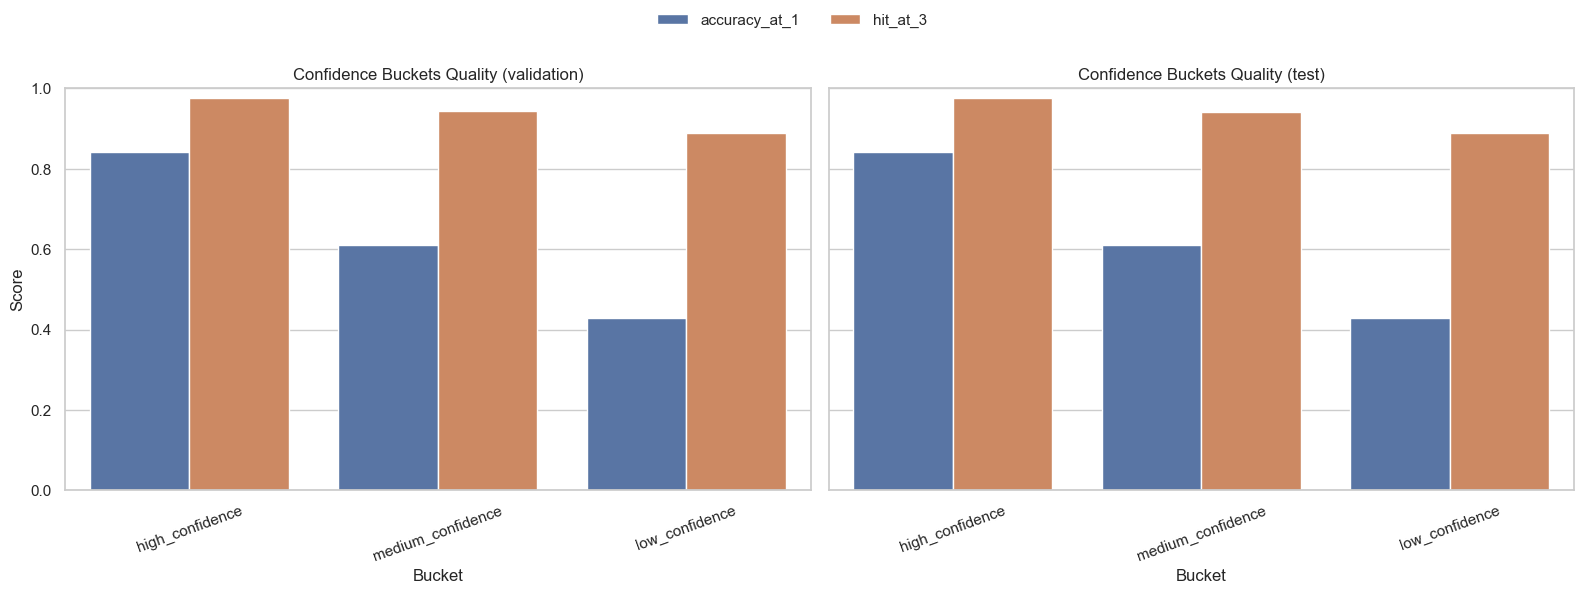

Saved figure: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\recommendation\confidence_buckets_quality_baseline.png


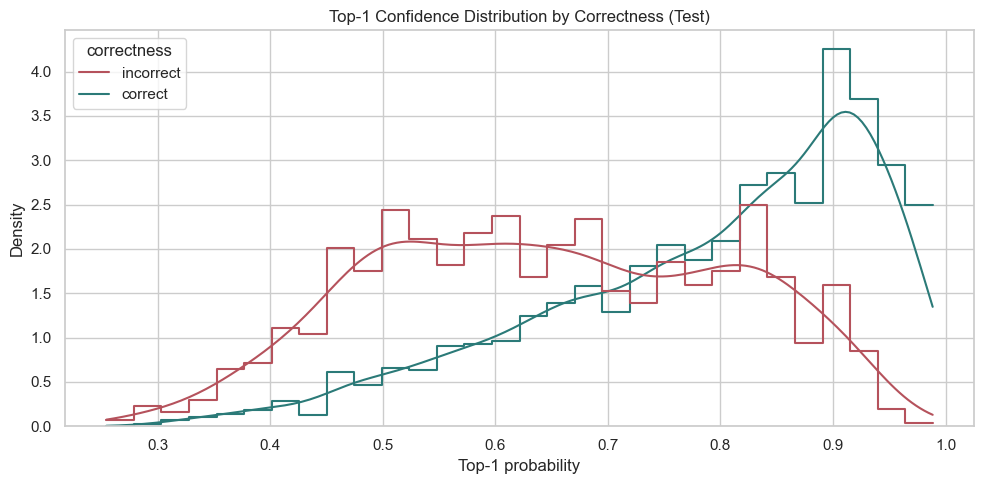

Saved figure: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\recommendation\top1_confidence_distribution_by_correctness_test_baseline.png
Saved table: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\recommendation\calibration_table_validation_baseline.csv


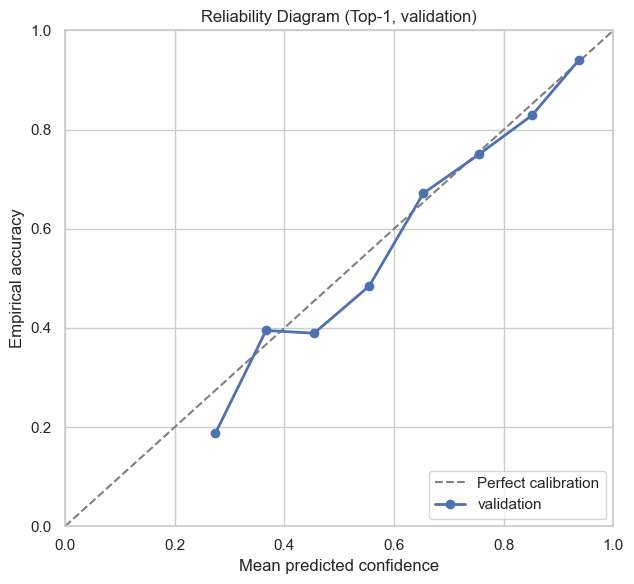

Saved figure: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\recommendation\reliability_diagram_validation_baseline.png
Saved table: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\recommendation\calibration_table_test_baseline.csv


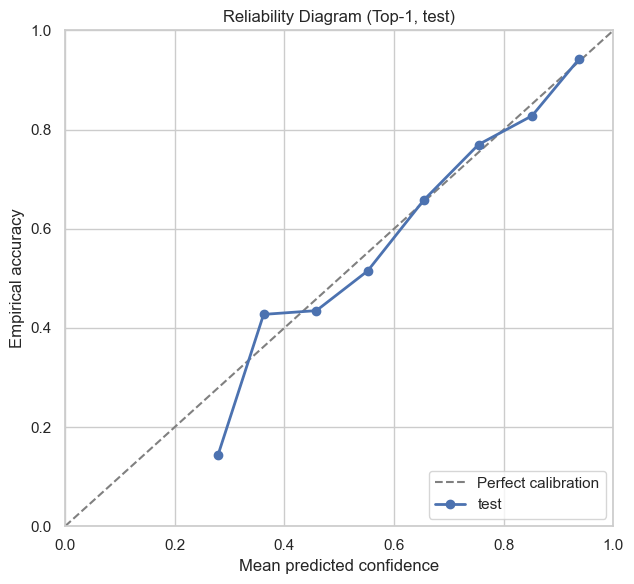

Saved figure: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\recommendation\reliability_diagram_test_baseline.png
Calibration metrics:


,split,ece_top1,brier_top1,mean_confidence,accuracy_at_1,n_samples
0,validation,0.023046,0.164402,0.750262,0.7356,5000
1,test,0.017367,0.161197,0.753980,0.7480,5000


Saved table: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\recommendation\calibration_metrics_baseline.csv


: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")


def load_csv_if_exists(path):
    path = Path(path)
    if not path.exists():
        return None
    return pd.read_csv(path)


def save_figure(fig, out_path, dpi=300):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    print("Saved figure:", out_path)
    plt.close(fig)


def compute_top1_calibration_table(df, n_bins=10):
    work = df.copy()
    work = work.dropna(subset=["top1_proba", "is_top1_correct"]).copy()
    if work.empty:
        return pd.DataFrame()

    work["top1_proba"] = pd.to_numeric(work["top1_proba"], errors="coerce")
    work["is_top1_correct"] = work["is_top1_correct"].astype(int)
    work = work.dropna(subset=["top1_proba"]).copy()
    work["top1_proba"] = work["top1_proba"].clip(0.0, 1.0)

    edges = np.linspace(0.0, 1.0, n_bins + 1)
    edges_list = edges.tolist()
    work["bin_id"] = pd.cut(
        work["top1_proba"],
        bins=edges_list,
        include_lowest=True,
        labels=False,
    )

    calib = (
        work.groupby("bin_id", dropna=True)
        .agg(
            n_samples=("is_top1_correct", "size"),
            mean_confidence=("top1_proba", "mean"),
            empirical_accuracy=("is_top1_correct", "mean"),
        )
        .reset_index()
    )
    calib["bin_left"] = calib["bin_id"].map(lambda x: float(edges[int(x)]))
    calib["bin_right"] = calib["bin_id"].map(lambda x: float(edges[int(x) + 1]))
    calib["abs_gap"] = (calib["mean_confidence"] - calib["empirical_accuracy"]).abs()

    total_n = float(calib["n_samples"].sum())
    ece = float((calib["n_samples"] * calib["abs_gap"]).sum() / total_n) if total_n > 0 else np.nan
    brier_top1 = float(np.mean((work["top1_proba"] - work["is_top1_correct"]) ** 2))
    avg_conf = float(work["top1_proba"].mean())
    acc = float(work["is_top1_correct"].mean())

    metrics = {
        "ece_top1": ece,
        "brier_top1": brier_top1,
        "mean_confidence": avg_conf,
        "accuracy_at_1": acc,
        "n_samples": int(len(work)),
    }
    return calib, metrics


results_dir = ROOT / "artifacts" / "results" / "recommendation"
results_dir.mkdir(parents=True, exist_ok=True)

confidence_summary_file = results_dir / f"confidence_summary_{active_model}.csv"
rec_val_file = results_dir / f"rec_val_preview_{active_model}.csv"
rec_test_file = results_dir / f"rec_test_preview_{active_model}.csv"

confidence_summary_art = load_csv_if_exists(confidence_summary_file)
rec_val_art = load_csv_if_exists(rec_val_file)
rec_test_art = load_csv_if_exists(rec_test_file)

if confidence_summary_art is None and "confidence_summary_df" in globals():
    confidence_summary_art = confidence_summary_df.copy()
if rec_val_art is None and "rec_val_df" in globals():
    rec_val_art = rec_val_df.copy()
if rec_test_art is None and "rec_test_df" in globals():
    rec_test_art = rec_test_df.copy()

# 1) Metrics by confidence buckets.
if confidence_summary_art is None or confidence_summary_art.empty:
    print("Confidence bucket plot skipped: table not found.")
    print("Searched:")
    print(" -", confidence_summary_file)
else:
    needed = {"split", "uncertainty_bucket", "accuracy_at_1"}
    if not needed.issubset(set(confidence_summary_art.columns)):
        print("Confidence summary table misses required columns.")
        print("Found columns:", confidence_summary_art.columns.tolist())
    else:
        bucket_order = ["high_confidence", "medium_confidence", "low_confidence"]
        cdf = confidence_summary_art.copy()
        cdf["uncertainty_bucket"] = pd.Categorical(cdf["uncertainty_bucket"], categories=bucket_order, ordered=True)

        value_cols = [c for c in ["accuracy_at_1", "hit_at_3"] if c in cdf.columns]
        bucket_plot_df = cdf.melt(
            id_vars=["split", "uncertainty_bucket"],
            value_vars=value_cols,
            var_name="metric",
            value_name="value",
        )

        fig1, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
        for i, split_name in enumerate(["validation", "test"]):
            sdf = bucket_plot_df[bucket_plot_df["split"] == split_name].copy()
            if sdf.empty:
                axes[i].set_visible(False)
                continue
            sns.barplot(data=sdf, x="uncertainty_bucket", y="value", hue="metric", ax=axes[i], palette="deep")
            axes[i].set_title(f"Confidence Buckets Quality ({split_name})")
            axes[i].set_xlabel("Bucket")
            axes[i].set_ylabel("Score")
            axes[i].set_ylim(0, 1)
            axes[i].tick_params(axis="x", rotation=20)

        handles, labels = axes[0].get_legend_handles_labels()
        if handles:
            fig1.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
        for ax in axes:
            if ax.get_legend() is not None:
                ax.get_legend().remove()
        fig1.tight_layout(rect=(0, 0, 1, 0.92))
        save_figure(fig1, results_dir / f"confidence_buckets_quality_{active_model}.png")

# 2) Distribution of top-1 confidence for correct vs incorrect.
if rec_test_art is None or rec_test_art.empty:
    print("Top-1 confidence distribution skipped: test preview not found.")
    print("Searched:")
    print(" -", rec_test_file)
else:
    test_conf_df = rec_test_art.copy()
    if "top1_proba" not in test_conf_df.columns:
        print("top1_proba column is missing in test preview; distribution plot skipped.")
    else:
        if "is_top1_correct" not in test_conf_df.columns and {"top1_pred", "target"}.issubset(test_conf_df.columns):
            test_conf_df["is_top1_correct"] = (
                test_conf_df["top1_pred"].astype("string") == test_conf_df["target"].astype("string")
            )

        if "is_top1_correct" not in test_conf_df.columns:
            print("No correctness flag available; plotting overall top1_proba distribution only.")
            fig2, ax2 = plt.subplots(figsize=(9, 5))
            sns.histplot(data=test_conf_df, x="top1_proba", bins=25, kde=True, color="#4C72B0", ax=ax2)
            ax2.set_title("Top-1 Confidence Distribution (Test)")
            ax2.set_xlabel("Top-1 probability")
            ax2.set_ylabel("Count")
            fig2.tight_layout()
            save_figure(fig2, results_dir / f"top1_confidence_distribution_test_{active_model}.png")
        else:
            test_conf_df["correctness"] = np.where(test_conf_df["is_top1_correct"].astype(bool), "correct", "incorrect")
            fig2, ax2 = plt.subplots(figsize=(10, 5))
            sns.histplot(
                data=test_conf_df,
                x="top1_proba",
                hue="correctness",
                bins=30,
                stat="density",
                common_norm=False,
                element="step",
                fill=False,
                kde=True,
                palette={"correct": "#2B7A78", "incorrect": "#B5525C"},
                ax=ax2,
            )
            ax2.set_title("Top-1 Confidence Distribution by Correctness (Test)")
            ax2.set_xlabel("Top-1 probability")
            ax2.set_ylabel("Density")
            fig2.tight_layout()
            save_figure(fig2, results_dir / f"top1_confidence_distribution_by_correctness_test_{active_model}.png")

# 3) Reliability diagram + calibration metrics (top-1).
if rec_val_art is None and rec_test_art is None:
    print("Calibration plots skipped: both val/test previews are unavailable.")
else:
    calib_rows = []
    for split_name, split_df in [("validation", rec_val_art), ("test", rec_test_art)]:
        if split_df is None or split_df.empty:
            continue
        if "top1_proba" not in split_df.columns:
            print(f"Calibration skipped for {split_name}: top1_proba is missing.")
            continue
        if "is_top1_correct" not in split_df.columns:
            if {"top1_pred", "target"}.issubset(split_df.columns):
                split_df = split_df.copy()
                split_df["is_top1_correct"] = (
                    split_df["top1_pred"].astype("string") == split_df["target"].astype("string")
                )
            else:
                print(f"Calibration skipped for {split_name}: no correctness labels.")
                continue

        calib_table, calib_metrics = compute_top1_calibration_table(split_df, n_bins=10)
        if isinstance(calib_table, pd.DataFrame) and not calib_table.empty:
            calib_table.insert(0, "split", split_name)
            calib_table.to_csv(results_dir / f"calibration_table_{split_name}_{active_model}.csv", index=False)
            print("Saved table:", results_dir / f"calibration_table_{split_name}_{active_model}.csv")

            fig3, ax3 = plt.subplots(figsize=(6.5, 6.0))
            ax3.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.5, label="Perfect calibration")
            ax3.plot(
                calib_table["mean_confidence"],
                calib_table["empirical_accuracy"],
                marker="o",
                linewidth=2,
                color="#4C72B0",
                label=f"{split_name}",
            )
            ax3.set_title(f"Reliability Diagram (Top-1, {split_name})")
            ax3.set_xlabel("Mean predicted confidence")
            ax3.set_ylabel("Empirical accuracy")
            ax3.set_xlim(0, 1)
            ax3.set_ylim(0, 1)
            ax3.legend(loc="lower right")
            fig3.tight_layout()
            save_figure(fig3, results_dir / f"reliability_diagram_{split_name}_{active_model}.png")

        calib_row = {"split": split_name}
        calib_row["ece_top1"] = calib_metrics.get("ece_top1", np.nan)
        calib_row["brier_top1"] = calib_metrics.get("brier_top1", np.nan)
        calib_row["mean_confidence"] = calib_metrics.get("mean_confidence", np.nan)
        calib_row["accuracy_at_1"] = calib_metrics.get("accuracy_at_1", np.nan)
        calib_row["n_samples"] = calib_metrics.get("n_samples", 0)
        calib_rows.append(calib_row)

    if calib_rows:
        calibration_metrics_df = pd.DataFrame(calib_rows)
        calibration_metrics_df.to_csv(results_dir / f"calibration_metrics_{active_model}.csv", index=False)
        print("Calibration metrics:")
        display(calibration_metrics_df)
        print("Saved table:", results_dir / f"calibration_metrics_{active_model}.csv")